# Seasonal Agriculture Performance Analysis

## Project Overview

Agricultural performance can vary considerably across seasons due to changes in environmental conditions, farming practices, resource availability, and market conditions.

This project analyzes an agricultural dataset to investigate how agricultural performance differs across the **Kharif, Rabi, and Zaid seasons**. The analysis focuses on identifying meaningful patterns, trends, relationships, and variations in environmental conditions, crop performance, resource usage, water efficiency, disease and pest risk, and economic outcomes.

The objective is to transform the available agricultural data into meaningful insights that can support evidence-based agricultural planning and seasonal decision-making.

---

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. These variations can affect crop yield, resource efficiency, disease and pest risk, production, revenue, and profitability.

This project aims to analyze the agricultural dataset and investigate differences in agricultural performance across seasons by identifying meaningful patterns, trends, relationships, and variations.

---

## Objectives

1. Explore and understand the agricultural dataset and its structure.
2. Clean and prepare the data for analysis.
3. Examine agricultural performance across different seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between seasonal environmental conditions and agricultural outcomes.
6. Compare crop performance across seasons.
7. Analyze resource usage and water efficiency across seasons and irrigation methods.
8. Examine economic outcomes such as revenue, cost, and profitability.
9. Identify significant differences, unusual patterns, and potential areas for further investigation.
10. Apply appropriate statistical and visualization techniques to validate observations.
11. Interpret the analytical results and derive evidence-based insights.
12. Develop data-driven recommendations for seasonal agricultural planning.

---

## Key Analytical Questions

- How does agricultural performance vary across Kharif, Rabi, and Zaid seasons?
- What major seasonal patterns can be observed in environmental conditions?
- How does crop yield change across seasons?
- Which crops show greater consistency or resilience across seasons?
- How does irrigation method relate to crop performance and water efficiency?
- How do environmental conditions relate to agricultural outcomes?
- How do revenue, cost, and profitability vary across seasons?
- How does disease and pest risk differ between seasons?
- Are the observed seasonal differences statistically significant?
- What unusual patterns or variations require further investigation?
- What insights can support better seasonal agricultural planning?

---

## Analytical Framework

The analysis follows the relationship:

**Seasonal Conditions → Agricultural Performance → Crop Response → Resource Efficiency → Economic Performance → Risk → Statistical Evidence → Recommendations**

---

## Expected Outcome

The final analysis will provide a structured understanding of seasonal agricultural performance, supported by exploratory analysis, visualizations, statistical testing, and data-driven interpretation.

The findings will be used to identify important seasonal patterns, compare agricultural outcomes, highlight potential risks and opportunities, and develop practical recommendations for seasonal planning.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    kruskal,
    mannwhitneyu,
    spearmanr,
    chi2_contingency
)

from itertools import combinations

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Dataset Loading and Initial Exploration

The agricultural dataset is loaded from the project's `data` directory. The dataset contains farm-level observations covering environmental conditions, crop characteristics, resource usage, agricultural performance, economic outcomes, and disease/pest risk.

The initial exploration focuses on understanding the dataset structure, dimensions, variables, data types, and overall characteristics before performing data cleaning and statistical analysis.

In [3]:
# Load the dataset

data_path = "../data/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 4,000
Columns: 28


## 2.1 Dataset Preview

In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


## 2.2 Dataset Dimensions

In [6]:
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 4000
Number of variables: 28


## 2.3 Variables in the Dataset

In [7]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

## 2.4 Data Types

In [8]:
df.dtypes

Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 2.5 Descriptive Statistics

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 2.6 Categorical Variable Overview

In [11]:
categorical_columns = ["State", "District", "Crop", "Season", "Irrigation_Method"]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


# 3. Data Quality Assessment

Before performing statistical analysis or visualization, the dataset is assessed for data quality issues. This stage examines missing values, duplicate records, data types, categorical consistency, and potential invalid or unusual numerical values.

The purpose of this assessment is to understand the condition of the raw dataset and determine appropriate preprocessing decisions without unnecessarily removing valid observations.

## 3.1 Missing Value Analysis

In [12]:
# Check missing values in each column

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100)

missing_summary = pd.DataFrame({
    "Missing_Values": missing_values,
    "Missing_Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing_Values"] > 0
].sort_values("Missing_Values", ascending=False)

missing_summary

,Missing_Values,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [13]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 120


## 3.2 Duplicate Record Analysis

In [14]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
if duplicate_count == 0:
    print("No duplicate records were identified.")
else:
    print(f"{duplicate_count} duplicate records were identified.")

No duplicate records were identified.


## 3.3 Data Type Validation

In [16]:
# Display data types

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values
})

dtype_summary

,Column,Data_Type
0,Farm_ID,str
1,State,str
2,District,str
3,Crop,str
4,Season,str
5,Farm_Area_Hectares,float64
6,Rainfall_mm,float64
7,Avg_Temperature_C,float64
8,Humidity_pct,float64
9,Sunlight_Hours_Day,float64


In [17]:
print("Categorical variables:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nNumerical variables:")
print(df.select_dtypes(include=np.number).columns.tolist())

Categorical variables:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numerical variables:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


C:\Users\work\AppData\Local\Temp\ipykernel_8044\3105199777.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


## 3.4 Categorical Value Consistency

Categorical variables are examined to identify inconsistent labels, unexpected categories, or formatting differences that could affect grouping and comparison during the analysis.

In [18]:
# Check unique values in categorical variables

analytical_categorical_columns = [
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method"
]

for column in analytical_categorical_columns:
    print(f"\n{'=' * 50}")
    print(column)
    print(f"{'=' * 50}")
    print(df[column].unique())


State
<StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

District
<StringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str

Crop
<StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Season
<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Irrigation_Method
<StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


In [19]:
# Display frequency distributions of categorical variables

for column in analytical_categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## 3.5 Numerical Range Validation

Numerical variables are examined for their observed minimum, median, and maximum values. This helps identify potentially invalid values and understand the scale and variability of the dataset.

Extreme values are not automatically removed because large differences may represent legitimate variation between crops, farms, or agricultural conditions.

In [20]:
# Inspect minimum, median, and maximum values

numeric_summary = df.select_dtypes(
    include=["number"]
).describe().T[["min", "50%", "max"]]

numeric_summary

,min,50%,max
Farm_Area_Hectares,0.50,7.89,15.00
Rainfall_mm,80.00,582.00,"1,395.20"
Avg_Temperature_C,16.20,26.90,39.70
Humidity_pct,25.00,63.00,95.00
Sunlight_Hours_Day,3.50,7.30,11.00
Soil_pH,5.20,6.69,8.40
Soil_Moisture_pct,8.00,26.40,47.00
Nitrogen_kg_ha,40.00,120.10,220.00
Phosphorus_kg_ha,15.00,57.50,120.00
Potassium_kg_ha,30.00,105.10,200.00


In [21]:
range_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

df[range_columns].describe().T[["min", "50%", "max"]]

,min,50%,max
Farm_Area_Hectares,0.50,7.89,15.00
Rainfall_mm,80.00,582.00,"1,395.20"
Avg_Temperature_C,16.20,26.90,39.70
Humidity_pct,25.00,63.00,95.00
Sunlight_Hours_Day,3.50,7.30,11.00
Soil_pH,5.20,6.69,8.40
Soil_Moisture_pct,8.00,26.40,47.00
Nitrogen_kg_ha,40.00,120.10,220.00
Phosphorus_kg_ha,15.00,57.50,120.00
Potassium_kg_ha,30.00,105.10,200.00


## 3.6 Outlier and Extreme Value Consideration

The dataset contains variables with substantially different scales across crops. In particular, sugarcane may have considerably higher yield values per hectare compared with several other crops.

Therefore, extreme observations are not automatically treated as errors or removed.

Instead, the analysis will use median-based summaries, distribution-based visualizations, crop-specific comparisons, and robust statistical methods where appropriate.

A sensitivity analysis excluding sugarcane will also be considered when comparing overall yield patterns, allowing the effect of crop-scale differences to be examined separately from the general seasonal pattern.

# 4. Data Cleaning and Preparation

The dataset is cleaned while preserving the integrity of the primary agricultural outcomes.

Missing rainfall and soil moisture values are handled using season-specific median imputation because these variables are environmental measurements that vary by season.

Missing yield values are not imputed because yield is a primary outcome variable in this analysis. Instead, observations with missing yield are excluded only from analyses that specifically require yield.

In [22]:
# Create a separate copy for data cleaning

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaning dataset shape:", df_clean.shape)

Original dataset shape: (4000, 28)
Cleaning dataset shape: (4000, 28)


In [23]:
# Impute missing environmental values using season-specific medians

for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    df_clean[col] = df_clean.groupby("Season")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing Rainfall values after imputation:",
      df_clean["Rainfall_mm"].isnull().sum())

print("Missing Soil Moisture values after imputation:",
      df_clean["Soil_Moisture_pct"].isnull().sum())

Missing Rainfall values after imputation: 0
Missing Soil Moisture values after imputation: 0


In [24]:
# Check missing yield values

print(
    "Missing Yield values:",
    df_clean["Yield_Tonnes_Ha"].isnull().sum()
)

Missing Yield values: 32


In [25]:
# Create a dataset for analyses requiring non-missing yield

yield_df = df_clean.dropna(
    subset=["Yield_Tonnes_Ha"]
).copy()

print("Yield analysis dataset shape:", yield_df.shape)

Yield analysis dataset shape: (3968, 28)


In [26]:
# Compare missing values before and after cleaning

cleaning_summary = pd.DataFrame({
    "Original_Missing": df.isnull().sum(),
    "Cleaned_Missing": df_clean.isnull().sum()
})

cleaning_summary = cleaning_summary[
    (cleaning_summary["Original_Missing"] > 0) |
    (cleaning_summary["Cleaned_Missing"] > 0)
]

cleaning_summary

,Original_Missing,Cleaned_Missing
Rainfall_mm,48,0
Soil_Moisture_pct,40,0
Yield_Tonnes_Ha,32,32


# 5. Feature Engineering

Additional analytical variables are derived from the existing dataset to support more meaningful comparisons across farms of different sizes and production levels.

Per-hectare measures help normalize economic outcomes by farm area, while cost- and revenue-per-tonne measures provide additional insight into production economics.

A binary loss-making indicator is also created to support the analysis of economic risk across seasons, crops, and other agricultural categories.

## 5.1 Revenue per Hectare

In [27]:
# Calculate revenue generated per hectare

df_clean["Revenue_per_Ha"] = (
    df_clean["Revenue_INR"] / df_clean["Farm_Area_Hectares"]
)

df_clean[
    ["Farm_Area_Hectares", "Revenue_INR", "Revenue_per_Ha"]
].head()

,Farm_Area_Hectares,Revenue_INR,Revenue_per_Ha
0,0.53,30810,"58,132.08"
1,6.53,40401,"6,186.98"
2,4.86,190466,"39,190.53"
3,4.50,200740,"44,608.89"
4,4.21,193607,"45,987.41"


## 5.2 Profit per Hectare

In [28]:
# Calculate profit generated per hectare

df_clean["Profit_per_Ha"] = (
    df_clean["Profit_INR"] / df_clean["Farm_Area_Hectares"]
)

df_clean[
    ["Farm_Area_Hectares", "Profit_INR", "Profit_per_Ha"]
].head()

,Farm_Area_Hectares,Profit_INR,Profit_per_Ha
0,0.53,-11852,"-22,362.26"
1,6.53,-451950,"-69,211.33"
2,4.86,-124744,"-25,667.49"
3,4.50,-95704,"-21,267.56"
4,4.21,-144352,"-34,287.89"


## 5.3 Profit Margin

Profit margin represents the percentage of revenue retained as profit after accounting for total cost.

In [29]:
# Calculate profit margin

df_clean["Profit_Margin_pct"] = (
    df_clean["Profit_INR"] / df_clean["Revenue_INR"]
) * 100

df_clean[
    ["Revenue_INR", "Profit_INR", "Profit_Margin_pct"]
].head()

,Revenue_INR,Profit_INR,Profit_Margin_pct
0,30810,-11852,-38.47
1,40401,-451950,"-1,118.66"
2,190466,-124744,-65.49
3,200740,-95704,-47.68
4,193607,-144352,-74.56


## 5.4 Cost per Tonne

Cost per tonne represents the approximate production cost associated with each tonne of agricultural output.

In [30]:
# Calculate production cost per tonne

df_clean["Cost_per_Tonne"] = (
    df_clean["Total_Cost_INR"] / df_clean["Production_Tonnes"]
)

df_clean[
    ["Total_Cost_INR", "Production_Tonnes", "Cost_per_Tonne"]
].head()

,Total_Cost_INR,Production_Tonnes,Cost_per_Tonne
0,42662,1.30,"32,816.92"
1,492351,1.96,"251,199.49"
2,315210,2.53,"124,588.93"
3,296444,8.28,"35,802.42"
4,337959,9.30,"36,339.68"


## 5.5 Revenue per Tonne

Revenue per tonne represents the approximate revenue generated for each tonne of agricultural production.

In [31]:
# Calculate revenue per tonne

df_clean["Revenue_per_Tonne"] = (
    df_clean["Revenue_INR"] / df_clean["Production_Tonnes"]
)

df_clean[
    ["Revenue_INR", "Production_Tonnes", "Revenue_per_Tonne"]
].head()

,Revenue_INR,Production_Tonnes,Revenue_per_Tonne
0,30810,1.30,"23,700.00"
1,40401,1.96,"20,612.76"
2,190466,2.53,"75,283.00"
3,200740,8.28,"24,243.96"
4,193607,9.30,"20,817.96"


## 5.6 Loss-Making Farms

A binary indicator is created to identify observations where the reported profit is negative.

This indicator will later be used to compare the proportion of loss-making farms across seasons and crop groups.

In [32]:
# Identify loss-making observations

df_clean["Loss_Making"] = df_clean["Profit_INR"] < 0

df_clean["Loss_Making"].value_counts()

Loss_Making
False    2034
True     1966
Name: count, dtype: int64

In [33]:
# Calculate the overall loss-making rate

loss_making_rate = df_clean["Loss_Making"].mean() * 100

print(f"Overall loss-making rate: {loss_making_rate:.2f}%")

Overall loss-making rate: 49.15%


## 5.7 Validation of Engineered Features

The newly created variables are checked for missing values and infinite values to ensure that the calculations have been performed correctly.

In [34]:
# List of newly engineered variables

engineered_columns = [
    "Revenue_per_Ha",
    "Profit_per_Ha",
    "Profit_Margin_pct",
    "Cost_per_Tonne",
    "Revenue_per_Tonne",
    "Loss_Making"
]

df_clean[engineered_columns].head()

,Revenue_per_Ha,Profit_per_Ha,Profit_Margin_pct,Cost_per_Tonne,Revenue_per_Tonne,Loss_Making
0,"58,132.08","-22,362.26",-38.47,"32,816.92","23,700.00",True
1,"6,186.98","-69,211.33","-1,118.66","251,199.49","20,612.76",True
2,"39,190.53","-25,667.49",-65.49,"124,588.93","75,283.00",True
3,"44,608.89","-21,267.56",-47.68,"35,802.42","24,243.96",True
4,"45,987.41","-34,287.89",-74.56,"36,339.68","20,817.96",True


In [35]:
# Check missing values

print("Missing values:")
print(df_clean[engineered_columns].isnull().sum())

Missing values:
Revenue_per_Ha       0
Profit_per_Ha        0
Profit_Margin_pct    0
Cost_per_Tonne       0
Revenue_per_Tonne    0
Loss_Making          0
dtype: int64


In [36]:
# Check infinite values in numerical engineered features

engineered_numeric = [
    "Revenue_per_Ha",
    "Profit_per_Ha",
    "Profit_Margin_pct",
    "Cost_per_Tonne",
    "Revenue_per_Tonne"
]

print("Infinite values:")
print(np.isinf(df_clean[engineered_numeric]).sum())

Infinite values:
Revenue_per_Ha       0
Profit_per_Ha        0
Profit_Margin_pct    0
Cost_per_Tonne       0
Revenue_per_Tonne    0
dtype: int64


## 5.8 Summary of Engineered Metrics

In [37]:
df_clean[engineered_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Revenue_per_Ha,"4,000.00","80,215.11","58,262.57","4,439.47","42,325.16","67,082.98","96,800.41","422,793.51"
Profit_per_Ha,"4,000.00","13,555.02","58,939.07","-83,127.37","-25,353.73",778.69,"31,262.42","356,585.58"
Profit_Margin_pct,"4,000.00",-45.49,158.09,"-1,461.85",-60.19,1.15,32.89,85.92
Cost_per_Tonne,"4,000.00","55,624.86","54,260.61",568.36,"23,032.64","37,897.60","64,153.10","296,805.13"
Revenue_per_Tonne,"4,000.00","44,714.16","30,266.16","2,594.00","21,429.25","25,913.01","68,278.67","131,239.98"


# 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the major patterns, distributions, relationships, and variations present in the agricultural dataset.

The analysis focuses on seasonal differences in environmental conditions, agricultural performance, crop behavior, irrigation practices, resource efficiency, economic outcomes, and agricultural risk.

The EDA is structured around the following analytical dimensions:

- Seasonal and categorical distributions
- Environmental conditions across seasons
- Agricultural performance across seasons
- Crop-level and crop-season comparisons
- Irrigation and resource utilization
- Water-use efficiency
- Economic performance
- Disease and pest risk
- Relationships between environmental conditions and agricultural outcomes

The findings from this exploratory analysis will be used to identify important patterns and formulate hypotheses for subsequent statistical analysis.

## 6.1 Season Distribution

The dataset contains observations from three agricultural seasons: Kharif, Rabi, and Zaid.

Before comparing agricultural performance, it is important to understand how the observations are distributed across seasons. This provides context for later comparisons and helps identify whether some seasons contain substantially more records than others.

In [39]:
season_counts = df_clean["Season"].value_counts()

season_counts

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [40]:
season_percentage = (
    df_clean["Season"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

season_percentage

Season
Kharif   44.47
Rabi     40.67
Zaid     14.85
Name: proportion, dtype: float64

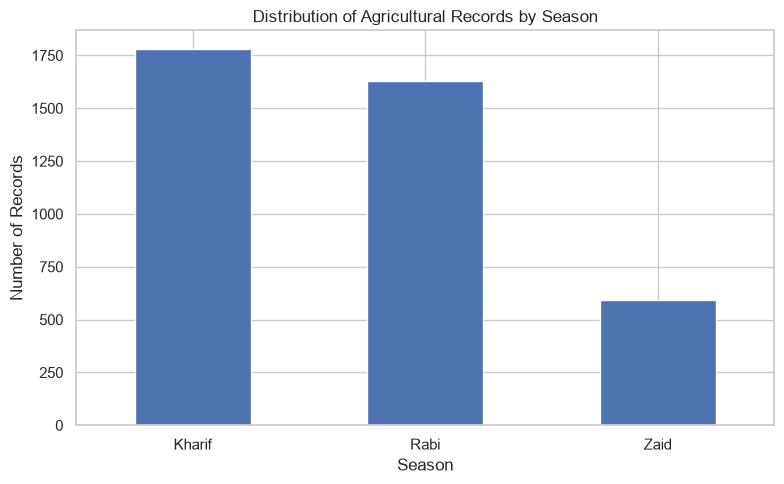

In [41]:
plt.figure(figsize=(8, 5))

season_counts.plot(kind="bar")

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains observations from all three agricultural seasons. Kharif has the largest number of records, followed by Rabi, while Zaid has the fewest observations.

The unequal number of observations should be considered when interpreting seasonal comparisons. Therefore, later analyses will focus on distributions, medians, percentages, and statistical tests rather than relying only on raw record counts.

## 6.2 Crop Distribution

Understanding the distribution of crops provides context for seasonal agricultural performance. Different crops may have substantially different production scales and economic characteristics, so crop composition should be examined before comparing outcomes across seasons.

In [42]:
crop_counts = df_clean["Crop"].value_counts()

crop_counts

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

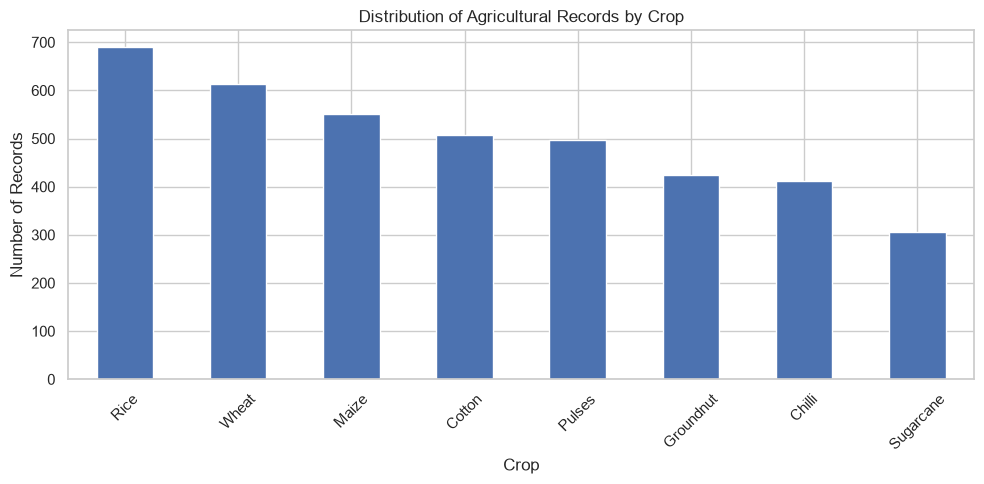

In [43]:
plt.figure(figsize=(10, 5))

crop_counts.plot(kind="bar")

plt.title("Distribution of Agricultural Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains eight different crops with varying numbers of observations. Rice, Wheat, and Maize have relatively large representation, while Sugarcane has fewer observations.

Because crops differ substantially in their production characteristics, crop-level and crop-season comparisons will be used alongside overall seasonal comparisons.

## 6.3 Irrigation Method Distribution

Irrigation is an important agricultural resource factor. Examining irrigation methods helps establish the resource-use context before investigating relationships between irrigation, seasonal conditions, yield, and water efficiency.

In [44]:
irrigation_counts = df_clean["Irrigation_Method"].value_counts()

irrigation_counts

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

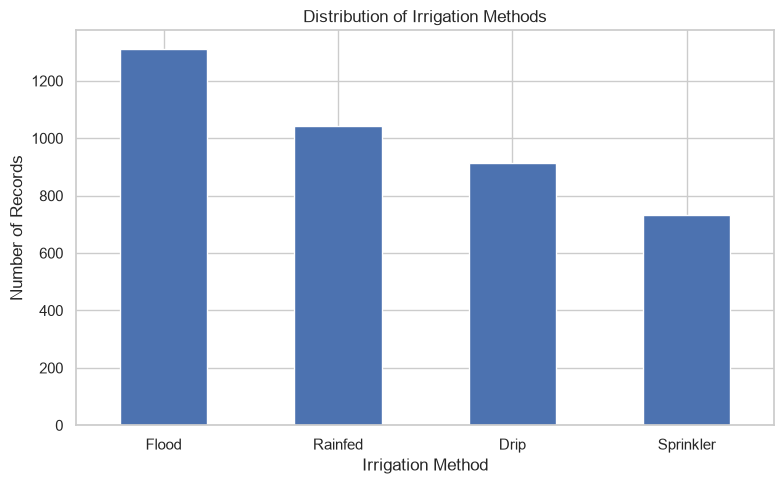

In [45]:
plt.figure(figsize=(8, 5))

irrigation_counts.plot(kind="bar")

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The dataset includes four irrigation methods: Flood, Rainfed, Drip, and Sprinkler.

Flood irrigation has the largest representation, while Sprinkler has the smallest. This distribution provides useful context for later analysis of irrigation methods, water usage, water efficiency, and seasonal yield.

## 6.4 Season × Crop Composition

Seasonal agricultural performance can be influenced by the crops represented in each season. Therefore, the distribution of crops across seasons is examined before interpreting seasonal differences in yield, profitability, and resource efficiency.

In [46]:
season_crop_counts = pd.crosstab(
    df_clean["Season"],
    df_clean["Crop"]
)

season_crop_counts

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


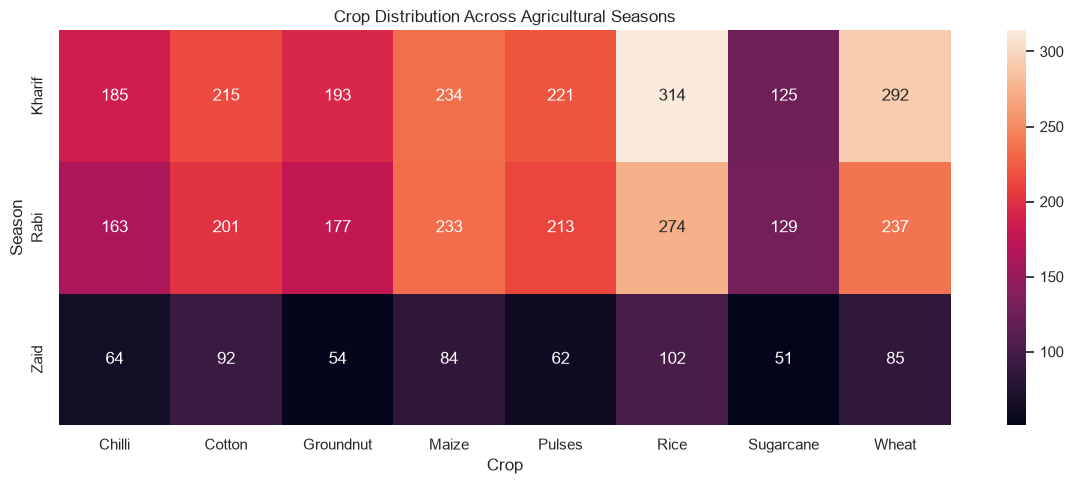

In [47]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    season_crop_counts,
    annot=True,
    fmt="d"
)

plt.title("Crop Distribution Across Agricultural Seasons")
plt.xlabel("Crop")
plt.ylabel("Season")

plt.tight_layout()
plt.show()

### Interpretation

The crop distribution across seasons is broadly comparable, although the number of observations differs between individual crop-season combinations.

This comparison is useful because it reduces the risk of interpreting seasonal performance differences without considering crop composition. Later statistical testing will further examine whether season and crop are significantly associated.

## 6.5 Seasonal Environmental Conditions

Now we get into the core story of the project.

We'll examine:

- Rainfall
- Temperature
- Humidity
- Soil moisture

These represent the environmental conditions associated with each season.

## 6.5.1 Seasonal Rainfall

Rainfall is one of the major environmental conditions associated with agricultural production. Comparing rainfall distributions across seasons helps establish the environmental differences that may be associated with subsequent changes in agricultural performance.

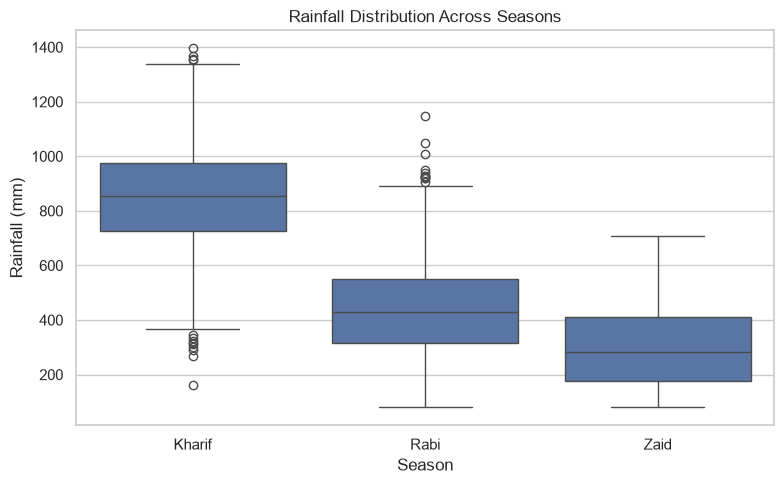

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Rainfall Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

In [49]:
df_clean.groupby("Season")["Rainfall_mm"].agg(
    ["count", "median", "mean", "min", "max"]
)

,count,median,mean,min,max
Season,,,,,
Kharif,1779,854.75,852.11,160.50,"1,395.20"
Rabi,1627,430.30,435.94,80.00,"1,146.50"
Zaid,594,283.30,299.12,80.00,708.30


### Interpretation

Rainfall differs substantially across the three agricultural seasons. Kharif records show considerably higher rainfall compared with Rabi and Zaid.

The seasonal reduction in rainfall provides an important environmental context for understanding later differences in soil moisture, yield, water efficiency, and economic performance.

## 6.5.2 Seasonal Temperature

Average temperature is examined across seasons to understand the thermal conditions associated with agricultural activity.

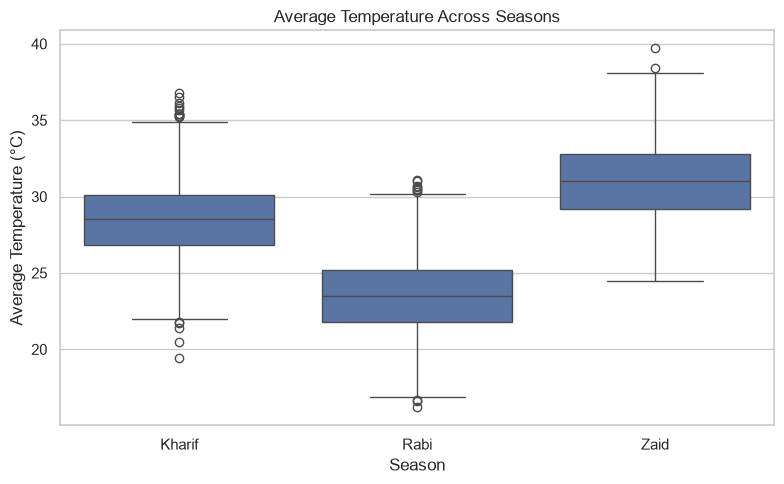

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Average Temperature Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")

plt.tight_layout()
plt.show()

In [51]:
df_clean.groupby("Season")["Avg_Temperature_C"].agg(
    ["median", "mean", "min", "max"]
)

,median,mean,min,max
Season,,,,
Kharif,28.50,28.45,19.40,36.80
Rabi,23.50,23.49,16.20,31.10
Zaid,31.00,31.04,24.50,39.70


### Interpretation

The seasons show clear differences in their temperature distributions. Kharif generally has warmer conditions than Rabi, while Zaid records the highest median temperature.

These differences provide environmental context for evaluating seasonal agricultural outcomes.

## 6.5.3 Seasonal Humidity

Humidity is examined as another environmental characteristic that may vary across agricultural seasons and may be associated with crop growing conditions and disease or pest risk.

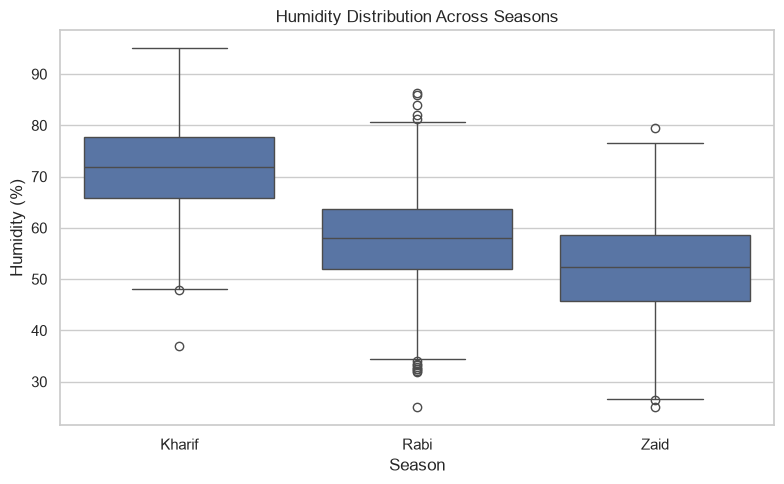

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Humidity_pct"
)

plt.title("Humidity Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Humidity (%)")

plt.tight_layout()
plt.show()

In [53]:
df_clean.groupby("Season")["Humidity_pct"].agg(
    ["median", "mean", "min", "max"]
)

,median,mean,min,max
Season,,,,
Kharif,71.90,71.81,36.90,95.00
Rabi,58.10,57.89,25.00,86.30
Zaid,52.35,52.01,25.00,79.50


## 6.5.4 Seasonal Soil Moisture

Soil moisture provides an indication of water availability within the agricultural environment. Its seasonal distribution is examined to understand how soil water conditions vary alongside rainfall and other environmental factors.

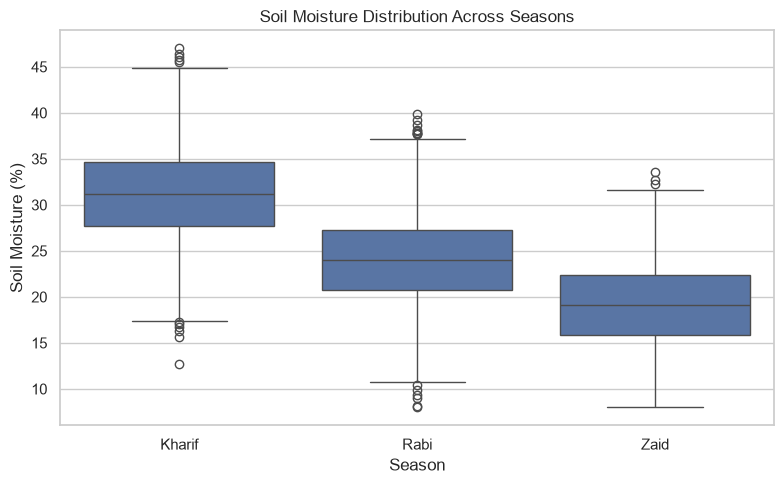

In [54]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Soil_Moisture_pct"
)

plt.title("Soil Moisture Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.tight_layout()
plt.show()

In [55]:
df_clean.groupby("Season")["Soil_Moisture_pct"].agg(
    ["median", "mean", "min", "max"]
)

,median,mean,min,max
Season,,,,
Kharif,31.20,31.20,12.70,47.00
Rabi,24.00,24.05,8.00,39.90
Zaid,19.10,19.17,8.00,33.60


## 6.6 Seasonal Environmental Summary

The major environmental variables are summarized by season to provide an overall view of the environmental differences observed in the dataset.

In [56]:
environmental_summary = df_clean.groupby("Season").agg({
    "Rainfall_mm": "median",
    "Avg_Temperature_C": "median",
    "Humidity_pct": "median",
    "Soil_Moisture_pct": "median"
})

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,
Kharif,854.75,28.50,71.90,31.20
Rabi,430.30,23.50,58.10,24.00
Zaid,283.30,31.00,52.35,19.10


### Key Environmental Observation

The environmental conditions show a clear seasonal pattern.

Kharif has the highest median rainfall, humidity, and soil moisture. Rabi has substantially lower rainfall and temperature, while Zaid has the lowest rainfall and soil moisture but the highest median temperature.

From Kharif to Zaid, median rainfall decreases substantially, while soil moisture also declines. These environmental differences provide the basis for investigating whether agricultural performance changes across seasons.

## 6.7 Seasonal Agricultural Performance

Agricultural performance is examined across Kharif, Rabi, and Zaid seasons using key outcome variables.

The analysis focuses on:

- Yield
- Water-use efficiency
- Disease and pest risk

Comparing these outcomes across seasons helps identify whether agricultural performance varies under different seasonal environmental conditions.

### 6.7.1 Yield Across Seasons

Yield is one of the primary indicators of agricultural performance. The distribution of yield across seasons is examined to identify differences in central tendency and variability.

Because the dataset contains crops with substantially different yield scales, both overall seasonal analysis and crop-level analysis will be considered when interpreting yield differences.

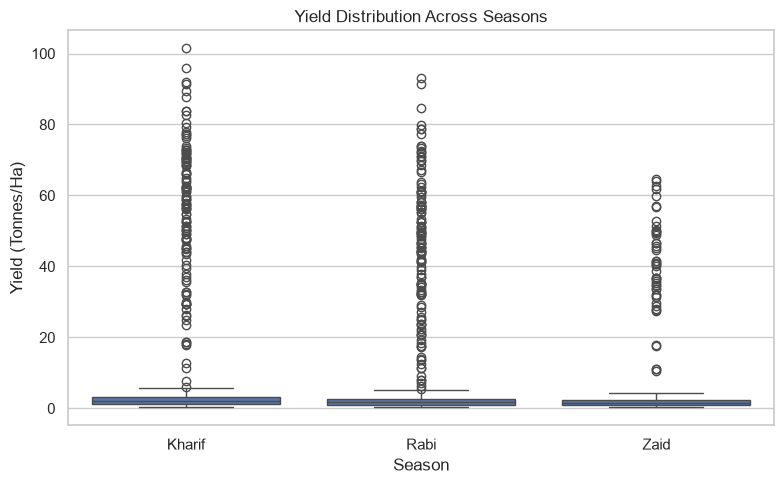

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=yield_df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [58]:
season_yield_summary = yield_df.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "median", "mean", "min", "max"]
)

season_yield_summary

,count,median,mean,min,max
Season,,,,,
Kharif,1772,1.95,5.64,0.30,101.44
Rabi,1607,1.66,5.08,0.30,93.13
Zaid,589,1.45,4.67,0.30,64.76


### Interpretation

Median yield shows a declining pattern from Kharif to Rabi and then to Zaid.

Kharif records the highest median yield, while Zaid records the lowest. This indicates that the dataset contains noticeable seasonal variation in agricultural productivity.

However, the yield distributions are strongly influenced by differences between crops. Therefore, crop-season analysis will be performed before drawing broader conclusions about seasonal performance.

### 6.7.2 Yield Sensitivity Analysis — Excluding Sugarcane

Sugarcane has a substantially different yield scale compared with the other crops in the dataset. Rather than treating these observations as errors or removing them from the main analysis, a sensitivity view excluding Sugarcane is used to examine whether the overall seasonal pattern remains visible among the remaining crops.

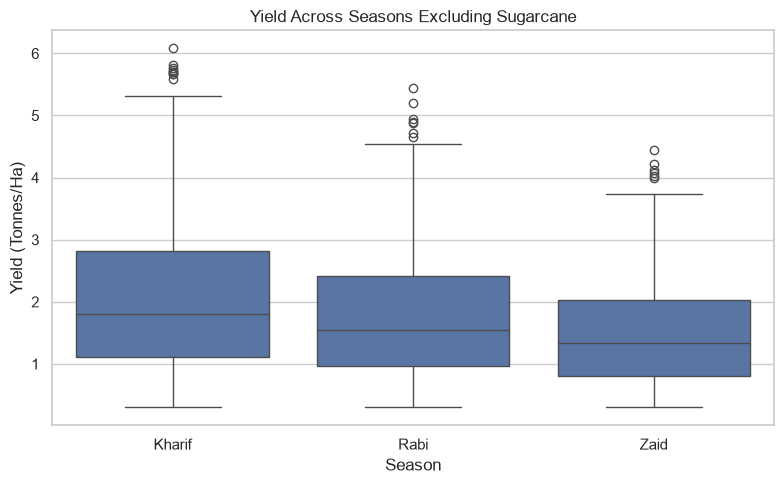

In [59]:
yield_without_sugarcane = yield_df[
    yield_df["Crop"] != "Sugarcane"
].copy()

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=yield_without_sugarcane,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Across Seasons Excluding Sugarcane")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [60]:
yield_without_sugarcane.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "median", "mean"]
)

,count,median,mean
Season,,,
Kharif,1647,1.81,2.02
Rabi,1480,1.54,1.75
Zaid,538,1.33,1.47


### Interpretation

Excluding Sugarcane provides a sensitivity view of seasonal yield differences among the remaining crops.

The comparison helps separate the seasonal pattern from the effect of crop-specific yield scales. Sugarcane is retained in the main dataset because its high yield values represent the characteristics of the crop rather than automatically indicating erroneous observations.

### 6.7.3 Water-Use Efficiency Across Seasons

Water-use efficiency measures agricultural output relative to water consumption.

Examining this indicator across seasons helps evaluate whether seasonal conditions are associated with differences in the efficiency of water utilization.

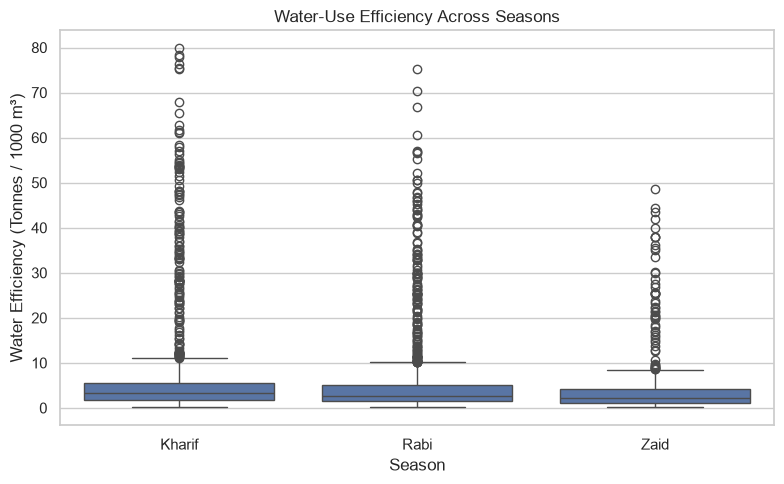

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Water_Efficiency_t_per_1000m3"
)

plt.title("Water-Use Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes / 1000 m³)")

plt.tight_layout()
plt.show()

In [62]:
water_efficiency_summary = df_clean.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].agg(
    ["count", "median", "mean", "min", "max"]
)

water_efficiency_summary

,count,median,mean,min,max
Season,,,,,
Kharif,1779,3.28,5.89,0.14,79.80
Rabi,1627,2.74,5.19,0.15,75.34
Zaid,594,2.30,4.41,0.14,48.55


### Interpretation

Median water-use efficiency decreases from Kharif to Rabi and then to Zaid.

This indicates that the agricultural records in Kharif generally show higher output relative to water usage than those observed in Rabi and Zaid.

The relationship should be interpreted as an observed association within the dataset rather than evidence that season directly causes changes in water-use efficiency.

### 6.7.4 Disease and Pest Risk Across Seasons

Disease and pest risk is examined across seasons to understand how agricultural risk varies under different seasonal conditions.

This analysis is particularly relevant because disease and pest pressure can influence crop performance and agricultural decision-making.

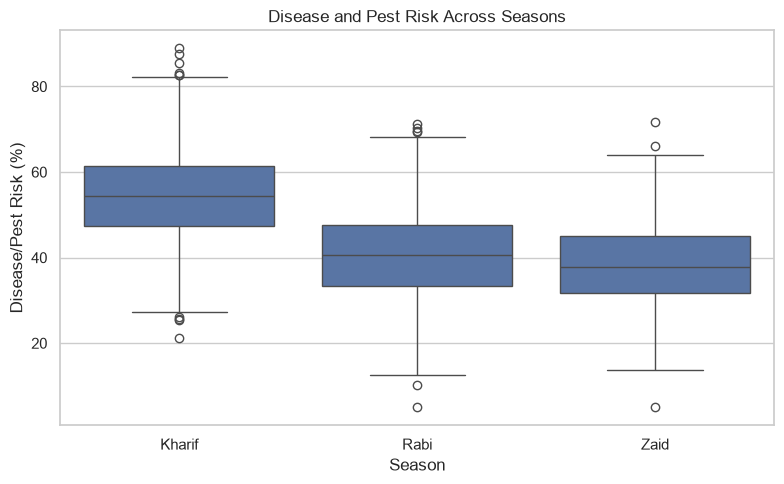

In [63]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Disease_Pest_Risk_pct"
)

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")

plt.tight_layout()
plt.show()

In [64]:
risk_summary = df_clean.groupby("Season")[
    "Disease_Pest_Risk_pct"
].agg(
    ["count", "median", "mean", "min", "max"]
)

risk_summary

,count,median,mean,min,max
Season,,,,,
Kharif,1779,54.50,54.47,21.30,88.90
Rabi,1627,40.60,40.48,5.10,71.20
Zaid,594,37.90,38.22,5.00,71.60


### Interpretation

Kharif has the highest median disease and pest risk, while Zaid has the lowest median risk.

This creates an important contrast with the performance indicators: Kharif shows relatively higher median yield and water-use efficiency but also higher reported disease and pest risk.

This suggests that seasonal agricultural performance should not be evaluated using yield alone. Both productivity and agricultural risk need to be considered when developing seasonal recommendations.

### 6.7.5 Seasonal Performance Summary

The major agricultural performance indicators are summarized by season to provide a consolidated view of productivity, resource efficiency, and agricultural risk.

In [65]:
season_performance_summary = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "median",
    "Water_Efficiency_t_per_1000m3": "median",
    "Disease_Pest_Risk_pct": "median",
    "Profit_per_Ha": "median"
})

season_performance_summary

,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_per_Ha
Season,,,,
Kharif,1.95,3.28,54.50,"8,340.45"
Rabi,1.66,2.74,40.60,-894.33
Zaid,1.45,2.30,37.90,"-13,760.26"


### Key Observation

The seasonal analysis shows a consistent decline in median yield and water-use efficiency from Kharif to Rabi and Zaid.

At the same time, Kharif records the highest median disease and pest risk.

These findings indicate that seasonal agricultural performance involves a trade-off between productivity, resource efficiency, and agricultural risk. Further crop-level and statistical analysis is required to determine whether these differences are consistent across individual crops and statistically significant.

# 6.8 Crop × Season Analysis

Agricultural performance can vary considerably between crops because different crops have different production characteristics, resource requirements, and economic outcomes.

Therefore, seasonal performance is further examined at the crop level to determine whether the patterns observed in the overall seasonal analysis are consistent across individual crops.

The analysis focuses on:

- Yield across crops and seasons
- Profitability across crops and seasons
- Crop resilience to seasonal variation

Median values are primarily used for crop-season comparisons because the dataset contains substantial differences in scale between crops and some variables contain extreme values.

### 6.8.1 Crop × Season Yield

The median yield of each crop is compared across Kharif, Rabi, and Zaid seasons.

This comparison helps identify crops that maintain relatively higher productivity across seasons and crops that show larger seasonal changes in yield.

In [66]:
crop_season_yield = pd.pivot_table(
    yield_df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="median"
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.78,1.56,1.22
Cotton,1.44,1.20,0.97
Groundnut,1.52,1.29,1.10
Maize,3.12,2.81,2.27
Pulses,1.09,0.90,0.66
Rice,2.88,2.38,1.94
Sugarcane,56.65,45.46,38.78
Wheat,2.36,2.23,1.84


### Crop × Season Yield Heatmap

A heatmap is used to provide a compact visual comparison of median yield across crops and seasons.

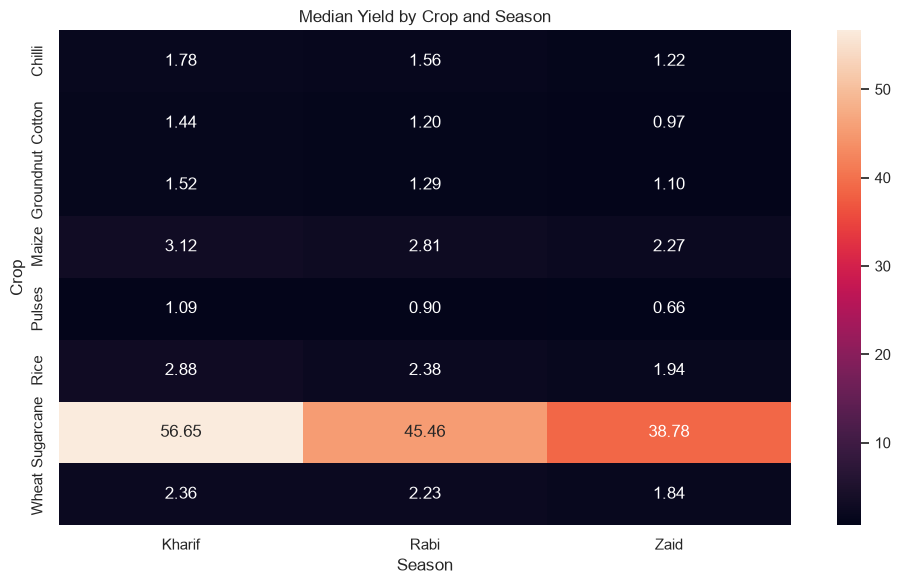

In [67]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Median Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### Interpretation

The crop-season heatmap shows that median yield varies across both crops and seasons.

Sugarcane has a substantially higher yield scale than the other crops, reflecting its crop-specific production characteristics. Among the remaining crops, Maize, Rice, and Wheat generally show higher median yields than Pulses, Cotton, and Groundnut.

A consistent decline in median yield from Kharif to Rabi and Zaid can be observed across all crops in the dataset. This suggests that the seasonal pattern identified in the overall analysis is also visible at the individual crop level.

### 6.8.2 Crop × Season Profitability

Yield does not necessarily translate into economic success because agricultural profitability depends on revenue and production costs.

Therefore, median profit per hectare is compared across crops and seasons to identify crops and seasons associated with stronger or weaker economic outcomes.

In [68]:
crop_season_profit = pd.pivot_table(
    df_clean,
    values="Profit_per_Ha",
    index="Crop",
    columns="Season",
    aggfunc="median"
)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"117,254.23","89,871.60","57,728.46"
Cotton,"29,143.88","14,213.69","-1,192.71"
Groundnut,"21,308.74","5,182.31","-5,126.72"
Maize,"-2,618.02","-11,671.96","-23,376.62"
Pulses,"12,163.67","-2,492.15","-18,523.98"
Rice,"-6,721.86","-12,897.46","-25,274.56"
Sugarcane,"130,325.00","90,924.65","73,367.83"
Wheat,"-12,129.08","-14,413.87","-24,341.77"


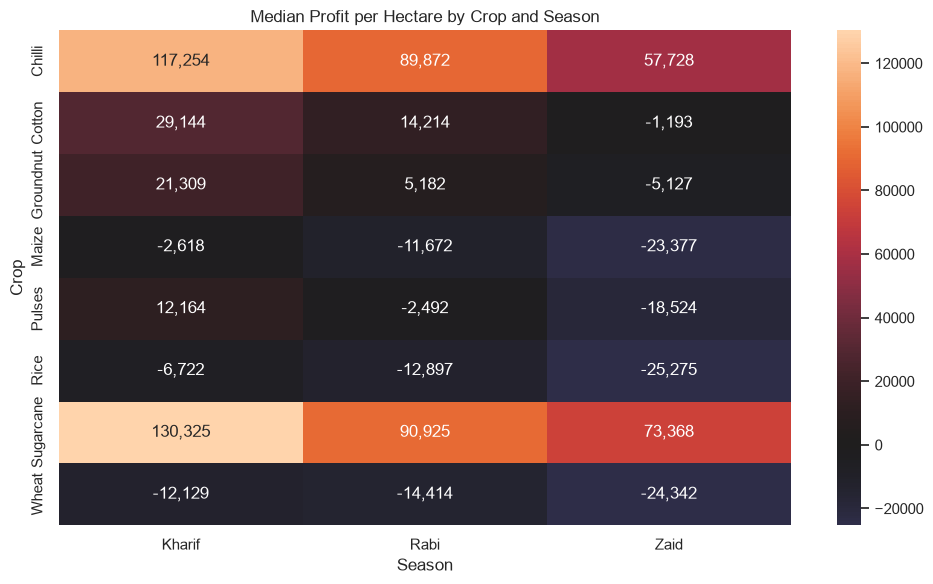

In [69]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt=",.0f",
    center=0
)

plt.title("Median Profit per Hectare by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### Interpretation

The profitability heatmap reveals substantial differences between crops and seasons.

Chilli and Sugarcane show positive median profit per hectare across all three seasons, although profitability decreases from Kharif to Zaid.

Cotton and Groundnut remain profitable in Kharif and Rabi but move close to or below zero in Zaid.

Maize, Rice, and Wheat show negative median profit per hectare across all three seasons, while Pulses transition from positive profitability in Kharif to negative profitability in Rabi and Zaid.

These results demonstrate why yield alone is insufficient for evaluating agricultural performance. Some crops may maintain reasonable productivity while still producing weak or negative economic outcomes.

### 6.8.3 Crop Resilience to Seasonal Variation

Crop resilience is examined by measuring the percentage change in median yield between Kharif and Zaid.

A smaller decline indicates that the crop maintained a greater proportion of its Kharif productivity under Zaid conditions, while a larger decline indicates greater sensitivity to seasonal variation.

This metric is used as a descriptive indicator rather than a definitive measure of agricultural resilience.

In [70]:
resilience_df = crop_season_yield.copy()

resilience_df["Yield_Change_Kharif_to_Zaid_pct"] = (
    (resilience_df["Zaid"] - resilience_df["Kharif"])
    / resilience_df["Kharif"]
) * 100

resilience_df[
    ["Kharif", "Zaid", "Yield_Change_Kharif_to_Zaid_pct"]
].sort_values(
    "Yield_Change_Kharif_to_Zaid_pct",
    ascending=False
)

Season,Kharif,Zaid,Yield_Change_Kharif_to_Zaid_pct
Crop,,,
Wheat,2.36,1.84,-22.03
Maize,3.12,2.27,-27.24
Groundnut,1.52,1.10,-27.96
Chilli,1.78,1.22,-31.46
Sugarcane,56.65,38.78,-31.54
Rice,2.88,1.94,-32.81
Cotton,1.44,0.97,-32.87
Pulses,1.09,0.66,-39.45


### Crop Yield Change from Kharif to Zaid

The percentage change in median yield from Kharif to Zaid is visualized to compare the degree of seasonal yield reduction across crops.

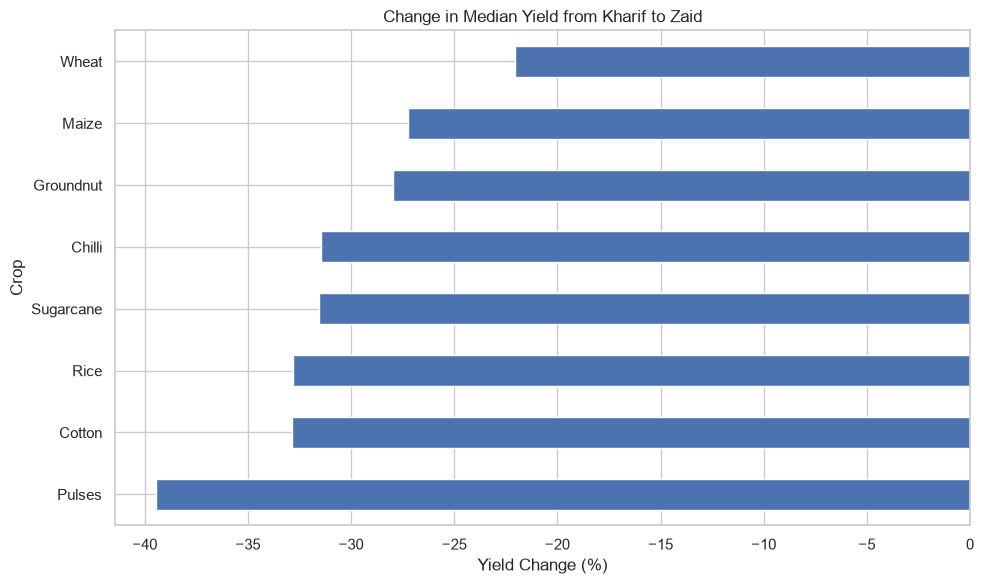

In [71]:
resilience_plot = (
    resilience_df[
        "Yield_Change_Kharif_to_Zaid_pct"
    ]
    .sort_values()
)

plt.figure(figsize=(10, 6))

resilience_plot.plot(kind="barh")

plt.title("Change in Median Yield from Kharif to Zaid")
plt.xlabel("Yield Change (%)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### Interpretation

All crops show a negative change in median yield from Kharif to Zaid, indicating lower median productivity in Zaid for every crop represented in the dataset.

The magnitude of the decline differs between crops. Crops with smaller percentage reductions demonstrate relatively greater yield stability across the two seasons, while crops with larger reductions show greater sensitivity to seasonal variation.

This crop-level resilience analysis provides a more detailed perspective than comparing overall seasonal averages alone.

### 6.8.4 Crop-Season Performance Summary

Yield, profitability, and seasonal yield change are combined into a single summary table to support comparison between crops.

In [72]:
crop_season_summary = crop_season_yield.copy()

crop_season_summary["Profit_Kharif"] = crop_season_profit["Kharif"]
crop_season_summary["Profit_Rabi"] = crop_season_profit["Rabi"]
crop_season_summary["Profit_Zaid"] = crop_season_profit["Zaid"]

crop_season_summary["Yield_Change_Kharif_to_Zaid_pct"] = (
    (crop_season_summary["Zaid"] - crop_season_summary["Kharif"])
    / crop_season_summary["Kharif"]
) * 100

crop_season_summary

Season,Kharif,Rabi,Zaid,Profit_Kharif,Profit_Rabi,Profit_Zaid,Yield_Change_Kharif_to_Zaid_pct
Crop,,,,,,,
Chilli,1.78,1.56,1.22,"117,254.23","89,871.60","57,728.46",-31.46
Cotton,1.44,1.20,0.97,"29,143.88","14,213.69","-1,192.71",-32.87
Groundnut,1.52,1.29,1.10,"21,308.74","5,182.31","-5,126.72",-27.96
Maize,3.12,2.81,2.27,"-2,618.02","-11,671.96","-23,376.62",-27.24
Pulses,1.09,0.90,0.66,"12,163.67","-2,492.15","-18,523.98",-39.45
Rice,2.88,2.38,1.94,"-6,721.86","-12,897.46","-25,274.56",-32.81
Sugarcane,56.65,45.46,38.78,"130,325.00","90,924.65","73,367.83",-31.54
Wheat,2.36,2.23,1.84,"-12,129.08","-14,413.87","-24,341.77",-22.03


### Key Crop-Level Observation

The crop-season analysis demonstrates that seasonal effects are not uniform in magnitude across crops.

All crops show lower median yield in Zaid compared with Kharif, but the economic consequences differ considerably between crops.

Chilli and Sugarcane maintain positive median profitability across all seasons, whereas several other crops experience negative median profitability during Rabi and Zaid.

This highlights the importance of combining productivity, profitability, and seasonal stability when evaluating crop performance.

# 6.9 Irrigation and Resource Analysis

Irrigation is an important component of agricultural resource management. Different irrigation methods may be associated with differences in water consumption, crop productivity, and water-use efficiency.

This section examines irrigation practices from both agricultural performance and resource-utilization perspectives.

The analysis focuses on:

- Distribution of irrigation methods
- Yield across irrigation methods
- Irrigation performance across seasons
- Water usage across irrigation methods
- Water-use efficiency across irrigation methods and seasons

The analysis describes observed relationships in the dataset and does not assume that irrigation method directly causes differences in agricultural outcomes.

## 6.9.1 Irrigation Method Distribution

The distribution of irrigation methods is examined to understand the representation of different irrigation practices in the dataset before comparing their agricultural and resource-use outcomes.

In [73]:
irrigation_summary = df_clean["Irrigation_Method"].value_counts()

irrigation_summary

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

In [74]:
irrigation_percentage = (
    df_clean["Irrigation_Method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

irrigation_percentage

Irrigation_Method
Flood       32.75
Rainfed     26.02
Drip        22.88
Sprinkler   18.35
Name: proportion, dtype: float64

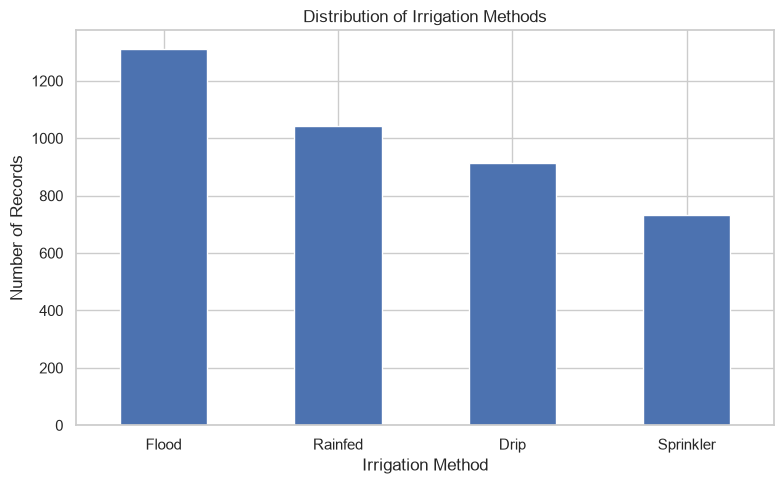

In [75]:
plt.figure(figsize=(8, 5))

irrigation_summary.plot(kind="bar")

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains four irrigation methods: Flood, Rainfed, Drip, and Sprinkler.

Flood irrigation has the largest representation, followed by Rainfed, Drip, and Sprinkler. The unequal representation of irrigation methods should be considered when interpreting comparisons of agricultural performance and resource efficiency.

## 6.9.2 Yield by Irrigation Method

The distribution of yield across irrigation methods is examined to identify differences in agricultural productivity associated with different irrigation practices.

Median yield is emphasized because the dataset contains substantial differences in crop-specific yield scales and potentially influential extreme values.

In [76]:
irrigation_yield_summary = yield_df.groupby(
    "Irrigation_Method"
)["Yield_Tonnes_Ha"].agg(
    ["count", "median", "mean", "min", "max"]
)

irrigation_yield_summary

,count,median,mean,min,max
Irrigation_Method,,,,,
Drip,907,1.96,6.62,0.30,101.44
Flood,1296,1.63,4.90,0.30,91.46
Rainfed,1037,1.72,4.61,0.30,77.32
Sprinkler,728,1.80,5.19,0.30,84.75


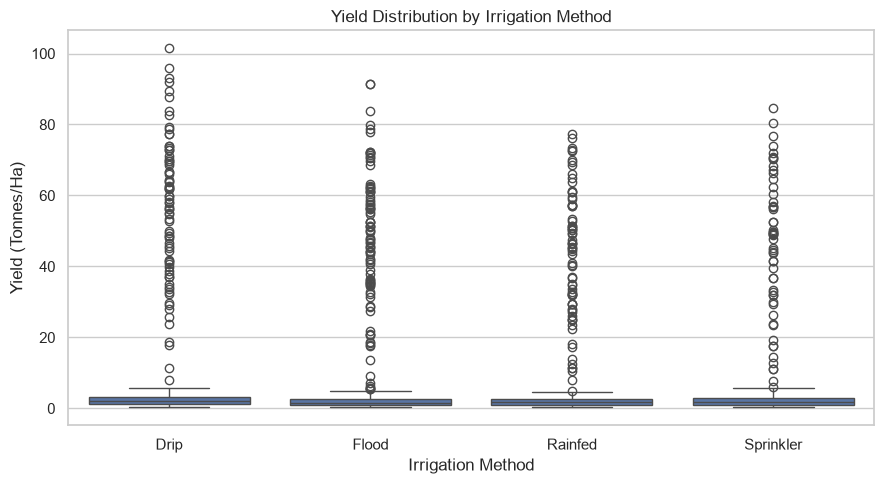

In [77]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=yield_df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

### Interpretation

Yield distributions differ across irrigation methods in the dataset.

However, these differences should not be interpreted as evidence that one irrigation method directly causes higher yield. Crop type, season, environmental conditions, farm characteristics, and other agricultural practices may also contribute to the observed differences.

Therefore, irrigation performance is further examined within individual seasons.

## 6.9.3 Irrigation × Season Yield

Overall irrigation comparisons may be influenced by seasonal conditions. Therefore, median yield is compared across irrigation methods within each agricultural season.

This provides a more detailed view of how irrigation practices are associated with yield under different seasonal conditions.

In [78]:
irrigation_season_yield = pd.pivot_table(
    yield_df,
    values="Yield_Tonnes_Ha",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="median"
)

irrigation_season_yield

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,2.14,1.85,1.52
Flood,1.88,1.59,1.21
Rainfed,1.86,1.60,1.46
Sprinkler,1.90,1.67,1.79


### Irrigation × Season Yield Heatmap

A heatmap is used to compare median yield across irrigation methods and agricultural seasons.

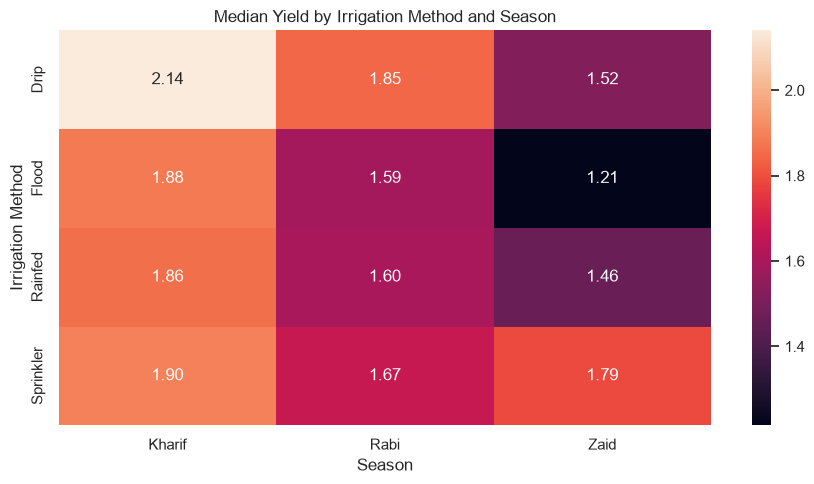

In [79]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    irrigation_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Median Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

### Interpretation

The relationship between irrigation method and yield varies across seasons.

Drip irrigation records the highest median yield among irrigation methods in Kharif and Rabi. In Zaid, Sprinkler irrigation records the highest median yield.

The results suggest that the relative performance of irrigation methods is not identical across seasons. This reinforces the importance of considering seasonal conditions when evaluating irrigation practices.

These findings represent observed associations within the dataset and should not be interpreted as causal effects.

## 6.9.4 Water Usage by Irrigation Method

Water consumption is examined across irrigation methods to understand differences in the amount of water used by farms following different irrigation practices.

This analysis provides a resource-utilization perspective alongside the yield analysis.

In [80]:
water_usage_summary = df_clean.groupby(
    "Irrigation_Method"
)["Water_Used_m3"].agg(
    ["count", "median", "mean", "min", "max"]
)

water_usage_summary

,count,median,mean,min,max
Irrigation_Method,,,,,
Drip,915,"4,606.00","5,918.75",167,28185
Flood,1310,"6,326.00","8,026.47",232,40902
Rainfed,1041,"2,782.00","3,549.55",128,16220
Sprinkler,734,"4,687.00","6,208.26",215,30397


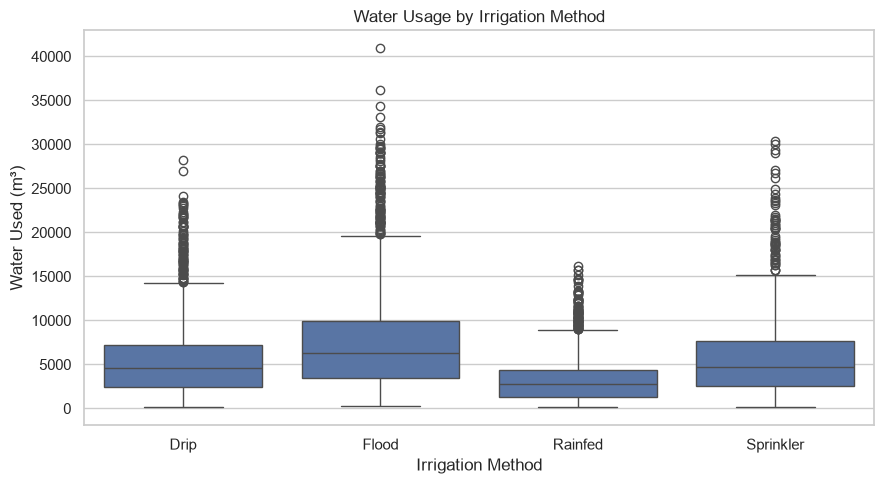

In [81]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Water_Used_m3"
)

plt.title("Water Usage by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.show()

### Interpretation

Water usage varies across irrigation methods in the dataset.

Differences in water consumption provide important context for evaluating irrigation performance. However, water usage alone does not indicate efficiency because farms may differ in area, crop type, and production volume.

Therefore, water-use efficiency is examined in the next analysis.

## 6.9.5 Water-Use Efficiency by Irrigation Method

Water-use efficiency measures agricultural output relative to water consumption.

Comparing this measure across irrigation methods provides a more meaningful assessment of resource utilization than examining total water usage alone.

In [82]:
irrigation_efficiency_summary = df_clean.groupby(
    "Irrigation_Method"
)["Water_Efficiency_t_per_1000m3"].agg(
    ["count", "median", "mean", "min", "max"]
)

irrigation_efficiency_summary

,count,median,mean,min,max
Irrigation_Method,,,,,
Drip,915,3.26,6.27,0.23,62.73
Flood,1310,1.95,3.44,0.14,42.82
Rainfed,1041,4.58,7.56,0.31,79.80
Sprinkler,734,2.65,4.67,0.19,52.19


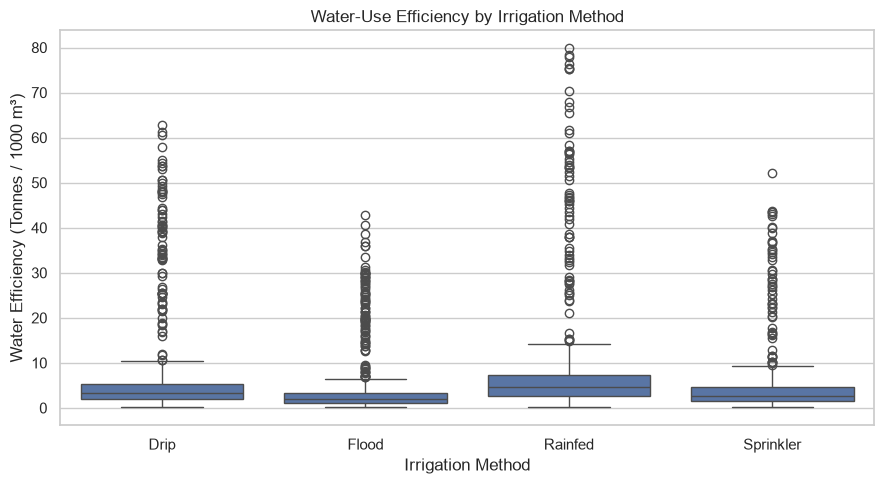

In [83]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3"
)

plt.title("Water-Use Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes / 1000 m³)")

plt.tight_layout()
plt.show()

### Interpretation

Water-use efficiency differs across irrigation methods, indicating variation in agricultural output relative to water consumption.

However, differences in crop composition, season, farm size, and environmental conditions may contribute to these observed patterns. Consequently, irrigation method should not be considered independently when making resource-management recommendations.

## 6.9.6 Irrigation × Season Water-Use Efficiency

Water-use efficiency is further compared across irrigation methods within each season.

This analysis helps determine whether the relative efficiency of irrigation practices remains consistent under different seasonal conditions.

In [84]:
irrigation_season_efficiency = pd.pivot_table(
    df_clean,
    values="Water_Efficiency_t_per_1000m3",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="median"
)

irrigation_season_efficiency

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,3.62,3.08,2.57
Flood,2.23,1.92,1.41
Rainfed,5.12,4.46,3.75
Sprinkler,2.80,2.58,2.36


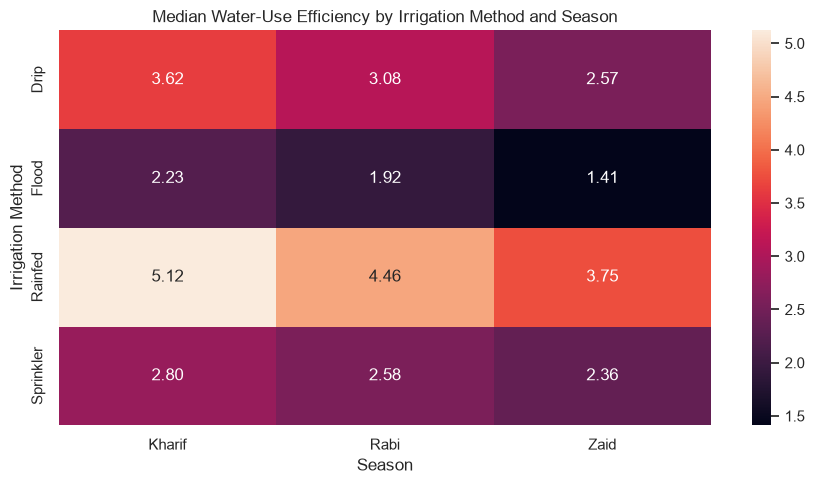

In [85]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    irrigation_season_efficiency,
    annot=True,
    fmt=".2f"
)

plt.title("Median Water-Use Efficiency by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

### Interpretation

Water-use efficiency varies across both irrigation methods and seasons.

The relative performance of irrigation methods changes under different seasonal conditions, indicating that irrigation efficiency should be evaluated within the environmental context in which the irrigation method is used.

This supports a more context-aware approach to agricultural resource management rather than recommending a single irrigation method for all seasons and farming conditions.

## 6.9.7 Irrigation and Resource Efficiency Summary

The major irrigation-related indicators are combined to provide a consolidated view of agricultural productivity and water-resource utilization.

In [86]:
irrigation_resource_summary = df_clean.groupby(
    "Irrigation_Method"
).agg({
    "Yield_Tonnes_Ha": "median",
    "Water_Used_m3": "median",
    "Water_Efficiency_t_per_1000m3": "median"
})

irrigation_resource_summary

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,
Drip,1.96,"4,606.00",3.26
Flood,1.63,"6,326.00",1.95
Rainfed,1.72,"2,782.00",4.58
Sprinkler,1.80,"4,687.00",2.65


### Key Observation

The irrigation analysis shows that irrigation methods differ in their observed yield, water consumption, and water-use efficiency.

The relationship between irrigation practices and agricultural performance also varies across seasons. Therefore, irrigation recommendations should consider seasonal conditions, crop characteristics, and resource-use efficiency together rather than relying on yield alone.

The results represent associations observed in the dataset and do not establish causal effects.